<div style="text-align: center; font-size: 1.5em;">
  <hr>
    EXPLORATORY NOTEBOOK: PROGRAM SYNTHESIS FOR ATTENTION HEADS
  <hr>
</div>
<div style="text-align: center; font-size: 1em; margin-top: 30px;">
Author: Amiri Hayes <br> MIT Summer Research Program 2025
<div>

In [19]:
import os
os.system('pip install -r requirements.txt')

# functions
import numpy as np
import pandas as pd
import torch   
import spacy
nlp = spacy.load("en_core_web_sm")
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize
import transformers
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
from transformers import PreTrainedTokenizerBase, PreTrainedModel
from openai import OpenAI
# data
import csv
import json
import requests
from dotenv import load_dotenv, find_dotenv
# visuals
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm, ListedColormap
import matplotlib.patches as mpatches
#helpers
from tqdm import tqdm
from typing import Optional, Tuple, Callable
load_dotenv(find_dotenv())
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"),)

print("Installs and imports completed successfully.")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\amkah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Installs and imports completed successfully.


In [1]:
# GET SENTENCE DATA
from sentences import retrieve_all_sentences
story_sentences, math_sentences, generic_sentences, qa_sentences, multilingual_sentences = \
retrieve_all_sentences()

print("Story Sentences:", story_sentences[:5])
print("Math Sentences:", math_sentences[:5])
print("Generic Sentences:", generic_sentences[:5])
print("QA Sentences:", qa_sentences[:5])
print("Multilingual Sentences:", multilingual_sentences[:5])

Story Sentences: ['One day, a little girl named Lily found a needle in her room.', 'She knew it was difficult to play with it because it was sharp.', 'Lily wanted to share the needle with her mom, so she could sew a button on her shirt.', 'Lily went to her mom and said, "Mom, I found this needle.', 'Can you share it with me and sew my shirt?"']
Math Sentences: ['Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\\theta),$ where $r > 0$ and $0 \\le \\theta < 2 \\pi.$', 'Define\n\\[p = \\sum_{k = 1}^\\infty \\frac{1}{k^2} \\quad \\text{and} \\quad q = \\sum_{k = 1}^\\infty \\frac{1}{k^3}.\\]Find a way to write\n\\[\\sum_{j = 1}^\\infty \\sum_{k = 1}^\\infty \\frac{1}{(j + k)^3}\\]in terms of $p$ and $q.$', 'If $f(x) = \\frac{3x-2}{x-2}$, what is the value of $f(-2) +f(-1)+f(0)$? Express your answer as a common fraction.', 'How many positive whole-number divisors does 196 have?', 'The results of a cross-country team\'s training r

In [2]:
len(math_sentences)

100

In [22]:
# GET MODEL AND TOKENIZER
from models import get_model_and_tokenizer
options = ["bert", "gpt-2", "tiny-llama"]
model_name = "tiny-llama"
tokenizer, model = get_model_and_tokenizer(model_name=model_name)
print(f"Loaded model and tokenizer for {model}")

Loaded model and tokenizer for LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,)

In [20]:
# IMPORT PATTERNS

from hypothesis_registry import hand_written_patterns, greedy_patterns, refined_patterns

patterns = hand_written_patterns() + greedy_patterns() + refined_patterns()
for func in patterns:
    globals()[func.__name__] = func
print(f"Total patterns loaded: {len(patterns)}")
print(f"Pattern names: {[p.__name__ for p in patterns]}")

decoder_patterns = [previous_attention, same_attention, cls_attention, relative_position_attention, uniform_attention, special_token_attention]

Total patterns loaded: 28
Pattern names: ['adjective_attention', 'chainofthought_pattern', 'cls_attention', 'constituent_attention', 'coreference_attention', 'dependencies', 'determiner_noun_phrase_linking', 'direct_object_prepositional_object_alignment', 'eos_attention', 'last_token_attention', 'linear_fit', 'negation_attention', 'next_attention', 'noun_modifier_attention', 'pos_alignment', 'preoposition_attention', 'previous_attention', 'pronoun_attention', 'punctuation_attention', 'relative_position_attention', 'repeated_attention', 'root_cluster_attention', 'same_attention', 'single_token_attention', 'special_token_attention', 'uniform_attention', 'verb_attention', 'verb_phrase_modifier_attention']


<div style="text-align: center; font-size: 1.5em;">
  <hr>
    Data & Pattern Initialization Functions
  <hr>
</div>

In [ ]:
import importlib.util
# import hypothesis_scoring
import models
# import hypothesis_registry
# importlib.reload(hypothesis_scoring)
# importlib.reload(hypothesis_registry)
importlib.reload(models)

<module 'models' from 'c:\\Users\\amkah\\OneDrive\\Documents\\GitHub\\LLM-Interpretability\\new\\models.py'>

In [25]:
import importlib.util
import visualization_plots
importlib.reload(visualization_plots)

<module 'visualization_plots' from 'c:\\Users\\amkah\\OneDrive\\Documents\\GitHub\\LLM-Interpretability\\new\\visualization_plots.py'>

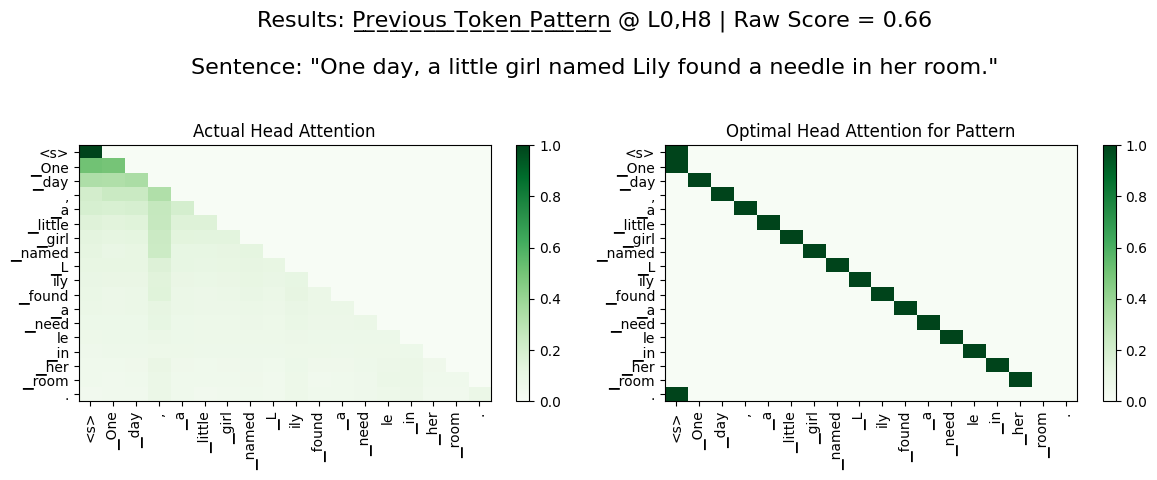

np.float64(0.6553791635317624)

In [ ]:
from hypothesis_scoring import score_prediction, classify_whole_model, linearly_combine_heads
from visualization_plots import visualize_full_model, filterer, visualize_highest_head

layer, head = 0, 8
score_prediction(model, tokenizer, (layer, head), previous_attention, story_sentences[0], distance="jsd", output=True)

In [11]:
best_fit_file = "C:\\Users\\amkah\\OneDrive\\Documents\\GitHub\\LLM-Interpretability\\data\\best_fit_tinyllama.csv"
activations = classify_whole_model(generic_sentences[:1], model, tokenizer, decoder_patterns, best_fit_file)


Currently Analyzing pattern: previous_attention
	Processing sentence 0/1
sentence #0| 1 19 0.5390134665039188
sentence #0| 1 30 0.3806709430264011
sentence #0| 14 30 0.3411423450309509
[[0.70219901 0.69641891 0.70461478 0.69919952 0.69948826 0.69803752
  0.69614316 0.70006864 0.69792224 0.69150815 0.69414511 0.70546839
  0.6921139  0.68948678 0.69830529 0.6962077  0.70061382 0.67800701
  0.675116   0.71329158 0.5701299  0.70972632 0.67454066 0.58650945
  0.69120035 0.69237052 0.69044626 0.70072312 0.69276747 0.70170526
  0.69590765 0.69550564]
 [0.65621871 0.66622981 0.6665861  0.60792105 0.68541424 0.70587733
  0.68441997 0.68685765 0.70102411 0.66924087 0.69751262 0.6774651
  0.6638989  0.69915113 0.68588952 0.70326487 0.68112007 0.64109994
  0.67795181 0.53901347 0.6427727  0.67018124 0.61397847 0.68890199
  0.71173391 0.64484644 0.66996081 0.66555401 0.68569975 0.66605862
  0.38067094 0.70817756]
 [0.675833   0.56034185 0.6004732  0.59951712 0.71856016 0.68720712
  0.69324478 0.68

C:\Users\amkah\AppData\Local\Temp\ipykernel_22464\2170165353.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_40 = plt.cm.get_cmap('tab20').colors + plt.cm.get_cmap('tab20b').colors
C:\Users\amkah\AppData\Local\Temp\ipykernel_22464\2170165353.py:143: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.1, 1, 1]) # Adjust layout to make space for the legend


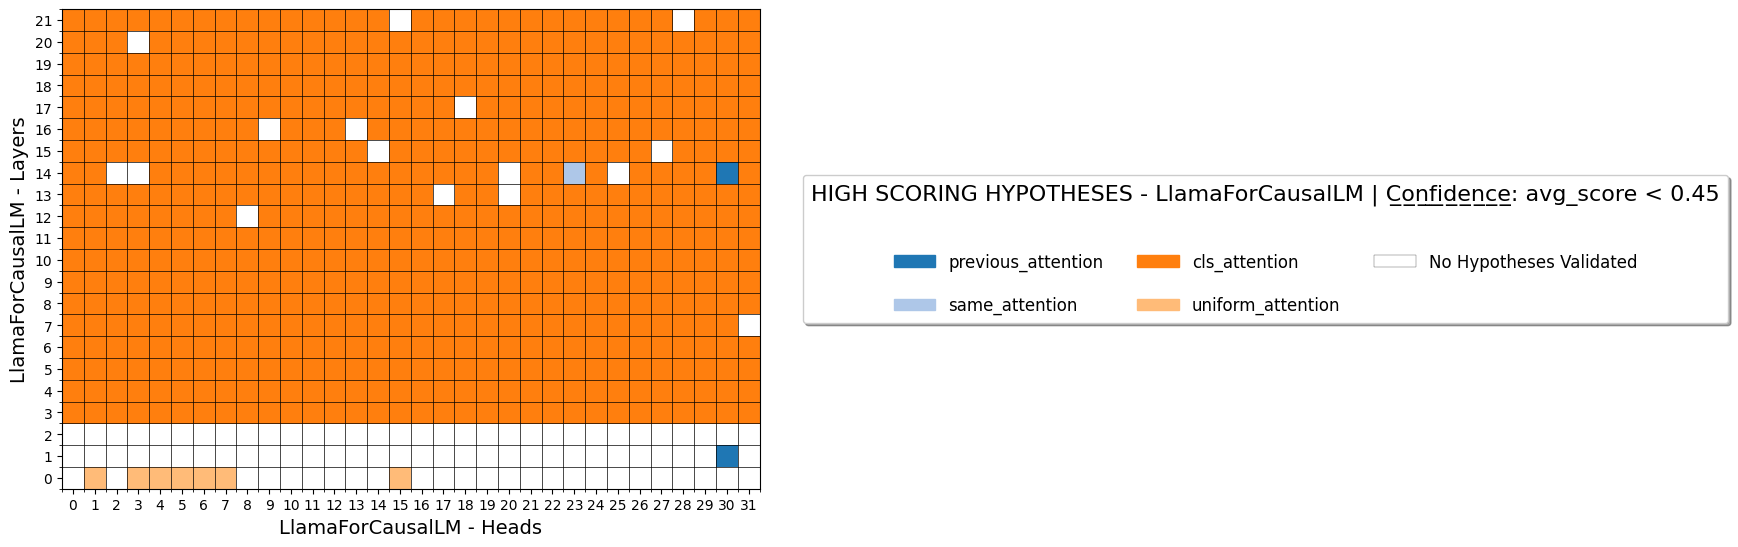

In [31]:
# VISUALIZE BEST FIT PATTERNS ACROSS LAYERS AND HEADS

# model = AutoModel.from_pretrained("roberta-base", output_attentions=True)
# tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# model = AutoModel.from_pretrained("openai-community/gpt2", output_attentions=True)
# tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")

# model = AutoModel.from_pretrained("bert-base-uncased", output_attentions=True)
# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

threshold = 0.45

from pathlib import Path

# C:\Users\amkah\OneDrive\Documents\GitHub\LLM-Interpretability\data\best_fit_tinyllama.csv
current_dir = Path().resolve()
# go up one level
# up_one_
data_dir = current_dir.parent / 'data' 
best_fit_csv = data_dir / 'best_fit_tinyllama.csv'
df = pd.read_csv(best_fit_csv)
# ignore columns where scores >= threshold
df = df[df['Score'] < threshold]
num_layers = model.config.num_hidden_layers
num_heads = model.config.num_attention_heads
mat = np.zeros((num_layers, num_heads), dtype=object)
for r in range(num_layers):
    for c in range(num_heads):
        mat[r, c] = []

for (i, j), group in df.groupby(['i', 'j']):
    sorted_group = group.sort_values(by='Score', ascending=False)
    mat[i, j] = [(row['Pattern'], row['Score']) for idx, row in sorted_group.iterrows()]

unique_patterns = df['Pattern'].unique()
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, to_rgb

colors_40 = plt.cm.get_cmap('tab20').colors + plt.cm.get_cmap('tab20b').colors
custom_cmap_40 = ListedColormap(colors_40, name='tab40')
cmap_patterns = plt.get_cmap(custom_cmap_40, len(unique_patterns))

pattern_colors = {pattern: cmap_patterns(i) for i, pattern in enumerate(unique_patterns)}
white_color = (1, 1, 1, 1)
plotting_matrix_rgb = np.zeros((num_layers, num_heads, 3))

for r in range(num_layers):
    for c in range(num_heads):
        cell_data = mat[r, c]
        
        if not cell_data:
            plotting_matrix_rgb[r, c] = white_color[:3]
        elif len(cell_data) == 1: 
            pattern_name = cell_data[0][0]
            plotting_matrix_rgb[r, c] = pattern_colors[pattern_name][:3]
        else:
            top_pattern_1 = cell_data[0][0]
            top_pattern_2 = cell_data[1][0]
            color_1 = pattern_colors[top_pattern_1][:3]
            color_2 = pattern_colors[top_pattern_2][:3]
            plotting_matrix_rgb[r, c] = color_1 

custom_draw_mask = np.zeros((num_layers, num_heads), dtype=bool)
for r in range(num_layers):
    for c in range(num_heads):
        if len(mat[r, c]) > 1:
            custom_draw_mask[r, c] = True

fig, ax = plt.subplots(figsize=(9, 18))
img = ax.imshow(plotting_matrix_rgb, origin='lower', extent=[-0.5, num_heads - 0.5, -0.5, num_layers - 0.5])

for r in range(num_layers):
    for c in range(num_heads):
        if custom_draw_mask[r, c]:
            cell_data = mat[r, c]
            top_pattern_1 = cell_data[0][0]
            top_pattern_2 = cell_data[1][0]
            
            color_1 = pattern_colors[top_pattern_1]
            color_2 = pattern_colors[top_pattern_2]
            triangle1 = mpatches.Polygon(
                [[c - 0.5, r - 0.5], [c + 0.5, r - 0.5], [c + 0.5, r + 0.5]],
                facecolor=color_1, edgecolor='none'
            )
            ax.add_patch(triangle1)
            triangle2 = mpatches.Polygon(
                [[c - 0.5, r - 0.5], [c - 0.5, r + 0.5], [c + 0.5, r + 0.5]],
                facecolor=color_2, edgecolor='none'
            )
            ax.add_patch(triangle2)

ax.set_xticks(np.arange(num_heads))
ax.set_yticks(np.arange(num_layers))
ax.set_xticks(np.arange(-0.5, num_heads, 1), minor=True)
ax.set_yticks(np.arange(-0.5, num_layers, 1), minor=True)
ax.set_xlabel(f'{model.config.architectures[0]} - Heads', fontsize=14)
ax.set_ylabel(f'{model.config.architectures[0]} - Layers', fontsize=14)
# center title across whole figure
# ax.set_title('What is GPT doing? - Best Fit Patterns Across All Heads and Layers', fontsize=18, pad=20, loc='center')
ax.set_aspect('equal')
# ax.grid(color='black', linestyle='-', linewidth=0.5)
ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5)

legend_handles = []
for pattern, color in pattern_colors.items():
    patch = mpatches.Patch(color=color, label=pattern)
    legend_handles.append(patch)

# center title
title_value_text = 'What is LLAMA doing? - Best Fit Patterns Across Attention Heads'
underlined_title_unicode = "".join([char + '\u0332' for char in title_value_text])
# plt.suptitle(underlined_title_unicode, fontsize=20, y=0.725, x=0.4)
# sort handles alphabetically by label
# legend_handles = sorted(legend_handles, key=lambda x: x.get_label())

white_patch = mpatches.Patch(facecolor=white_color, label='No Hypotheses Validated', edgecolor='black', linewidth=0.2)
legend_handles.append(white_patch)

name = 'Confidence'
underlined_name_unicode = "".join([char + '\u0332' for char in name])

ax.legend(
    handles=legend_handles, 
    loc='center left', 
    bbox_to_anchor=(1.05, 0.5),
    ncol=3, 
    fancybox=True, 
    shadow=True, 
    title=f"HIGH SCORING HYPOTHESES - {model.config.architectures[0]} | {underlined_name_unicode}: avg_score < {threshold}\n",
    title_fontsize=16,
    fontsize='large', # Make legend text bigger. Can use 'medium', 'x-large', 'xx-large' or a numerical value (e.g., 12)
    labelspacing=1.5, # Adjust vertical spacing between legend entries (default is 0.5)
    handlelength=2.5, # Adjust length of the color patch/line in the legend
    handletextpad=0.8, # Adjust space between the handle (color patch) and the text label
    borderpad=0.5 # Adjust padding between the legend content and its border 
) 

# plt.tight_layout()
# plt.show()

plt.tight_layout(rect=[0, 0.1, 1, 1]) # Adjust layout to make space for the legend
plt.show()